# Sarcasm Detection in News Headlines
**CA3: NLP Mini Project | Sukriti Singh | PRN 25030422121**

> **The story in one sentence:** *A fine-tuned DistilBERT scores very high at "sarcasm detection", but the audit shows it mostly learned **which newspaper wrote the headline** (The Onion vs HuffPost), and it struggles with everyday sarcasm.*

## Project Overview
* **Problem Statement:** Sarcasm relies on world knowledge and context, not explicit markers. This project builds a binary classifier that separates sarcastic news headlines from sincere ones, then *audits* whether it really understands sarcasm.
* **Dataset:** Misra's *News Headlines Dataset for Sarcasm Detection v2* (28,503 unique headlines). Sarcastic = *The Onion* (label 1), real = *HuffPost* (label 0).
* **Preprocessing:** Baselines: lowercase, strip punctuation, lemmatize (words > 3 letters), TF-IDF. DistilBERT reads the raw headline with its own tokenizer.
* **Approach:** TF-IDF + Logistic Regression / Naive Bayes / Linear SVC (simple, explainable) vs a fine-tuned **DistilBERT** (modern, contextual).
* **Results:** filled in automatically by the scoreboard in Section 6 and the one-page model card in Section 11, so the write-up can never disagree with the code.



## 1. Setup

In [ ]:
!pip -q install transformers datasets accelerate wordcloud lime shap

In [ ]:
import os, re, random, textwrap, warnings, zipfile
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)
import torch

warnings.filterwarnings('ignore'); nltk.download('wordnet', quiet=True)
SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


C_REAL, C_SARC, C_GREY = '#6BA6D6', '#E0457B', '#B8B8C8'
sns.set_theme(style='whitegrid')
plt.rcParams.update({'axes.titleweight': 'bold', 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})
os.makedirs('figs', exist_ok=True)
def save(name): plt.savefig(f'figs/{name}.png', dpi=200, bbox_inches='tight')   # slide-ready PNGs

DATA_PATH = 'Sarcasm_Headlines_Dataset_v2.json'
if not os.path.exists(DATA_PATH):
    from google.colab import files
    files.upload()

Saving Sarcasm_Headlines_Dataset_v2.json to Sarcasm_Headlines_Dataset_v2.json


## 2. Data
Misra's *News Headlines Dataset for Sarcasm Detection v2*. **Sarcastic = The Onion, real = HuffPost.** The label comes from the *outlet*, not from a human judging sarcasm. This is the project's central limitation, and the audit is built around it.


Headlines: 28503 | Sarcastic share: 47.5%


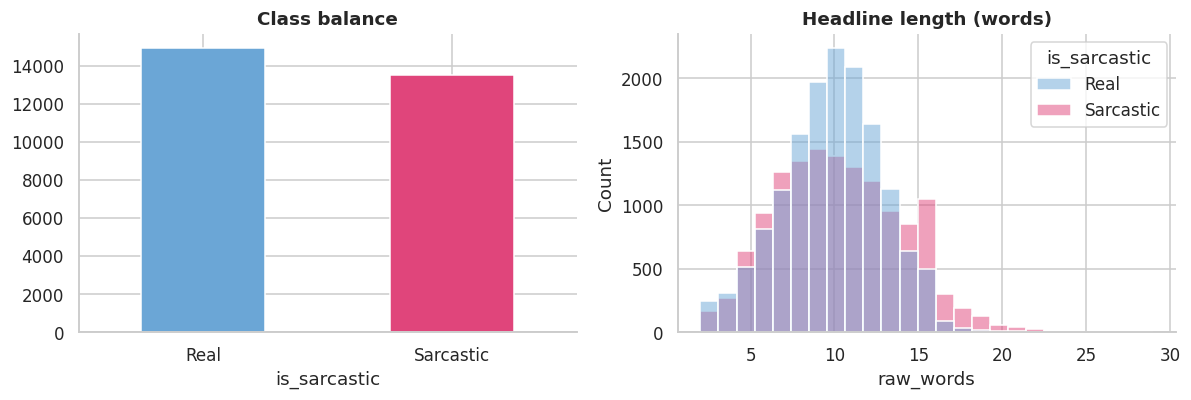

In [ ]:
df = pd.read_json(DATA_PATH, lines=True)[['headline', 'is_sarcastic']].drop_duplicates()
print("Headlines:", len(df), "| Sarcastic share: {:.1%}".format(df['is_sarcastic'].mean()))
df['raw_words'] = df['headline'].str.split().str.len()
lab = df['is_sarcastic'].map({0: 'Real', 1: 'Sarcastic'})

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
lab.value_counts().reindex(['Real', 'Sarcastic']).plot(kind='bar', ax=ax[0], color=[C_REAL, C_SARC], rot=0, title='Class balance')
keep = df.raw_words < 30
sns.histplot(x=df.loc[keep, 'raw_words'], hue=lab[keep], hue_order=['Real', 'Sarcastic'], bins=25,
             ax=ax[1], palette=[C_REAL, C_SARC]).set_title('Headline length (words)')
plt.tight_layout(); save('01_data'); plt.show()

## 3. Preprocessing
1. Lowercase and strip punctuation. 2. Lemmatize words longer than 3 letters (*cats → cat*; short words are skipped because WordNet turns *has* into *ha*). 3. TF-IDF drops stop words and keeps word pairs (bigrams).

*Used by the Logistic Regression baseline only. DistilBERT reads the **raw** headline with its own tokenizer.*


In [ ]:
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    return ' '.join(lemmatizer.lemmatize(w) if len(w) > 3 else w for w in text.split())

df['clean'] = df['headline'].apply(clean_text)
df['n_words'] = df['clean'].str.split().str.len()
print("Before:", df['headline'].iloc[0]); print("After :", df['clean'].iloc[0])

Before: thirtysomething scientists unveil doomsday clock of hair loss
After : thirtysomething scientist unveil doomsday clock of hair loss


## 4. Baseline models (TF-IDF)
TF-IDF (unigrams + bigrams, top 10,000 features) feeds three classifiers. **Logistic Regression** is the explainable baseline (one readable weight per word). Naive Bayes and Linear SVC are extra baselines. The 80/20 split uses a fixed seed. Logistic Regression's C is picked by 5-fold cross-validation on the **training set only**, so the test set is used once at the end.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['clean'], df['is_sarcastic'], test_size=0.2, random_state=SEED)
y_true = y_test.values

pipe = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000, stop_words='english')),
                 ('clf', LogisticRegression(max_iter=1000))])
grid = GridSearchCV(pipe, {'clf__C': [0.5, 1, 1.5, 3, 5]}, cv=5, scoring='accuracy').fit(X_train, y_train)
best_C = grid.best_params_['clf__C']; print("Chosen C:", best_C)

vec, log_model = grid.best_estimator_.named_steps['tfidf'], grid.best_estimator_.named_steps['clf']
X_tr, X_te = vec.transform(X_train), vec.transform(X_test)
nb_model  = MultinomialNB().fit(X_tr, y_train)
svm_model = CalibratedClassifierCV(LinearSVC(C=0.5), cv=5).fit(X_tr, y_train)

pred_log, prob_log = log_model.predict(X_te), log_model.predict_proba(X_te)[:, 1]
pred_nb,  prob_nb  = nb_model.predict(X_te),  nb_model.predict_proba(X_te)[:, 1]
pred_svm, prob_svm = svm_model.predict(X_te), svm_model.predict_proba(X_te)[:, 1]

Chosen C: 3


## 5. Fine-tuned DistilBERT
 BERT-style models have already read millions of sentences, so they know English but not *our task*. **Fine-tuning** = two short extra lessons on our headlines. DistilBERT is a smaller, faster BERT (about 40% smaller, keeps ~97% of the quality). Unlike TF-IDF it reads word order and context, but it is a black box, which is why Section 8 uses LIME.

*Needs a GPU (Runtime → T4). About 2-3 minutes. Uses the **same** train/test split as the baselines, so the comparison is fair.*

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL = 'distilbert-base-uncased'
tok = AutoTokenizer.from_pretrained(MODEL)
mk  = lambda idx, y: Dataset.from_dict({'text': df.loc[idx, 'headline'].tolist(), 'label': y.tolist()})
enc = lambda b: tok(b['text'], truncation=True, max_length=48, padding='max_length')
train_ds = mk(X_train.index, y_train).map(enc, batched=True)
test_ds  = mk(X_test.index,  y_test).map(enc, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)
args = TrainingArguments(output_dir='bert_out', num_train_epochs=2, per_device_train_batch_size=32,
                         learning_rate=2e-5, weight_decay=0.01, seed=SEED, report_to='none',
                         save_strategy='no', fp16=torch.cuda.is_available())
trainer = Trainer(model=model, args=args, train_dataset=train_ds)
trainer.train()

logits    = trainer.predict(test_ds).predictions
prob_bert = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
pred_bert = (prob_bert >= 0.5).astype(int)

def bert_proba(texts):
    """P(sarcastic) for a list of strings. Used by LIME, SHAP and the stress test."""
    model.eval(); out = []
    for i in range(0, len(texts), 64):
        b = tok(list(texts[i:i+64]), truncation=True, max_length=48, padding=True, return_tensors='pt').to(model.device)
        with torch.no_grad():
            out.append(torch.softmax(model(**b).logits, -1)[:, 1].cpu().numpy())
    return np.concatenate(out)

print(f"DistilBERT test accuracy: {accuracy_score(y_true, pred_bert):.3f}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/22802 [00:00<?, ? examples/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.313856
1000,0.193050


DistilBERT test accuracy: 0.920


## 6. Results
Precision, recall and F1 are for the **sarcastic** class.



,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.797,0.790,0.769,0.779,0.878
Naive Bayes,0.796,0.794,0.758,0.776,0.880
Linear SVC,0.797,0.788,0.771,0.779,0.878
DistilBERT,0.920,0.923,0.903,0.913,0.978


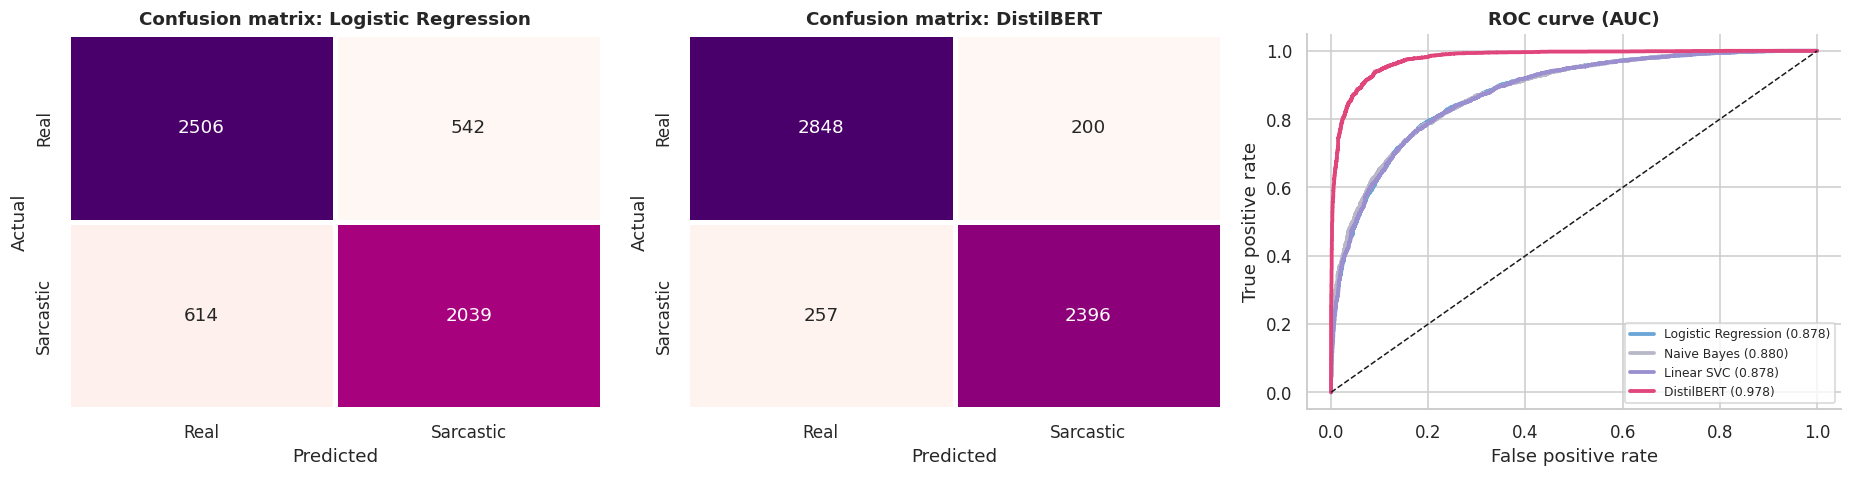

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)

assert 'pred_bert' in globals(), 'Run the DistilBERT cell in Section 5 first!'

MODELS = {'Logistic Regression': (pred_log, prob_log), 'Naive Bayes': (pred_nb, prob_nb),
          'Linear SVC': (pred_svm, prob_svm), 'DistilBERT': (pred_bert, prob_bert)}

def scores(y, pred, prob):
    return {'Accuracy': accuracy_score(y, pred), 'Precision': precision_score(y, pred),
            'Recall': recall_score(y, pred), 'F1': f1_score(y, pred), 'AUC': roc_auc_score(y, prob)}

results = pd.DataFrame({n: scores(y_true, p, pr) for n, (p, pr) in MODELS.items()}).T
display(results.style.background_gradient(cmap='RdPu', vmin=0.6, vmax=1.0).format('{:.3f}'))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for a, mn in zip(ax[:2], ['Logistic Regression', 'DistilBERT']):
    sns.heatmap(confusion_matrix(y_true, MODELS[mn][0]), annot=True, fmt='d', cmap='RdPu', cbar=False, ax=a,
                xticklabels=['Real', 'Sarcastic'], yticklabels=['Real', 'Sarcastic'], linewidths=2, linecolor='white')
    a.set(title=f'Confusion matrix: {mn}', xlabel='Predicted', ylabel='Actual')
for (mn, (p, pr)), col in zip(MODELS.items(), [C_REAL, C_GREY, '#9B8FD0', C_SARC]):
    fpr, tpr, _ = roc_curve(y_true, pr)
    ax[2].plot(fpr, tpr, lw=2.5, color=col, label=f"{mn} ({roc_auc_score(y_true, pr):.3f})")
ax[2].plot([0, 1], [0, 1], 'k--', lw=1)
ax[2].legend(loc='lower right', fontsize=8)
ax[2].set(title='ROC curve (AUC)', xlabel='False positive rate', ylabel='True positive rate')
plt.tight_layout()
save('02_results')
plt.show()

DistilBERT reaches 92.0% accuracy (F1 0.913, AUC 0.978) against 79.7% for TF-IDF + Logistic Regression, but a stress test shows it catches only 4 of 12 sarcastic texts, because it learned outlet style.

The histograms show **separation**: the further apart the pink and blue piles, the more confident (and the more outlet-driven) the model is.

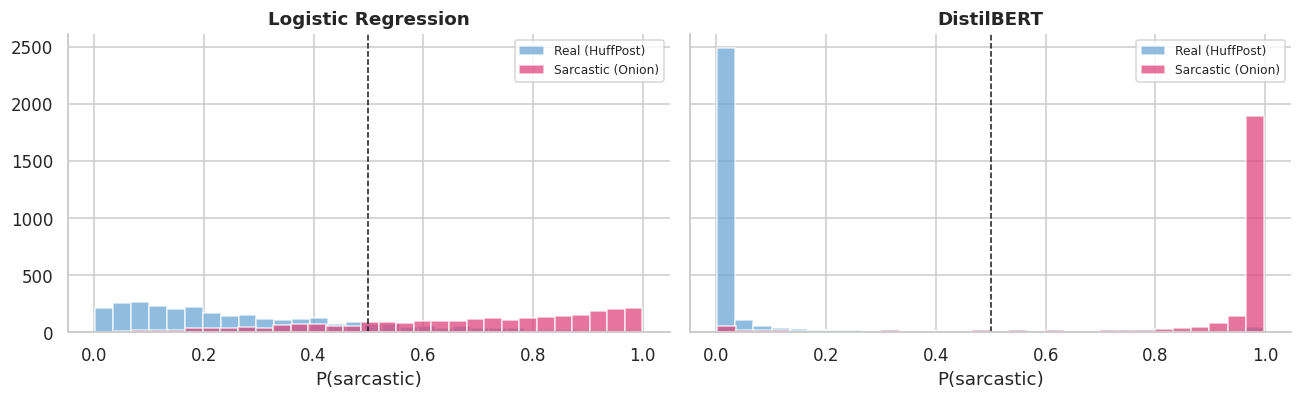

In [ ]:
# Separation plot: how far apart does each model push the two classes?
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for a, mn in zip(ax, ['Logistic Regression', 'DistilBERT']):
    pr = MODELS[mn][1]
    a.hist(pr[y_true == 0], bins=30, alpha=.75, color=C_REAL, label='Real (HuffPost)')
    a.hist(pr[y_true == 1], bins=30, alpha=.75, color=C_SARC, label='Sarcastic (Onion)')
    a.axvline(.5, color='k', ls='--', lw=1); a.set(title=mn, xlabel='P(sarcastic)'); a.legend(fontsize=8)
plt.tight_layout(); save('02b_separation'); plt.show()

## 7. Audit: performance across text subgroups
Five independent axes, each a simple rule so it is easy to explain: **Length**, **Style** (question or statement), **Numbers**, **Register** (casual/slang words) and **Voice** (first-person *I / my / we*, closer to everyday speech than to news). For each group: accuracy, sarcasm recall, and **false-positive rate** (real headlines wrongly flagged). `n_sarc` is the number of truly sarcastic headlines, so you can see when a group is too small to trust.



,Model,Axis,Group,n,n_sarc,Accuracy,Sarcasm recall,FPR
0,Logistic Regression,Length,Long (10+ words),3212,1445,0.812,0.792,0.171
1,Logistic Regression,Length,Short (<10 words),2489,1208,0.778,0.741,0.187
2,Logistic Regression,Style,Question (?),165,23,0.794,0.609,0.176
3,Logistic Regression,Style,Statement,5536,2630,0.797,0.770,0.178
4,Logistic Regression,Numbers,Has a digit,811,384,0.820,0.789,0.152
5,Logistic Regression,Numbers,No digit,4890,2269,0.793,0.765,0.182
6,Logistic Regression,Register,Casual / slang,93,72,0.925,0.917,0.048
7,Logistic Regression,Register,Neutral,5608,2581,0.795,0.764,0.179
8,Logistic Regression,Voice,First-person,308,46,0.786,0.543,0.172
9,Logistic Regression,Voice,Third-person,5393,2607,0.798,0.773,0.178


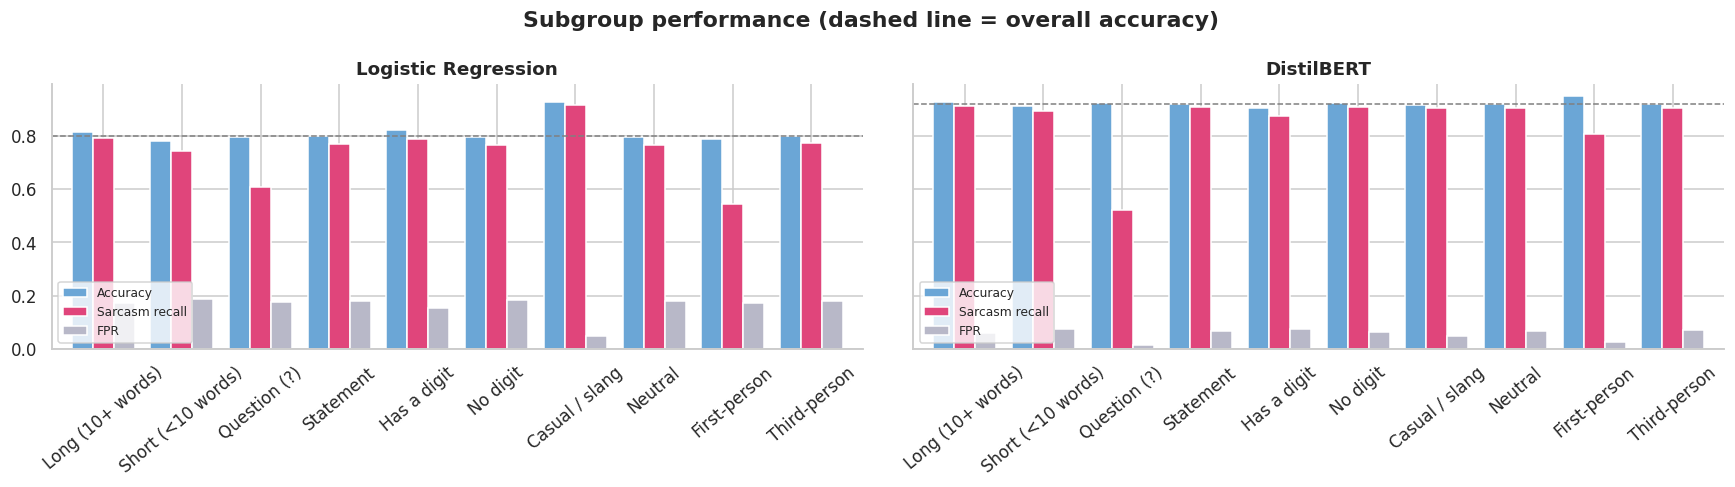

In [ ]:
test = df.loc[X_test.index].copy()
test['lr_prob'], test['bert_prob'] = prob_log, prob_bert
low = test['headline'].str.lower()
CASUAL = r"\b(?:fuck\w*|shit\w*|damn\w*|hell|crap|gonna|wanna|omg|lol|wtf|dude|bro|yeah|yep|nope|hey|wow|ugh|totally|literally|seriously)\b"
FIRST  = r"\b(?:i|me|my|mine|we|our|us|i'm|i've|i'll)\b"
axes = {  # axis: (name if True, name if False, mask on the test set)
    'Length':   ('Long (10+ words)', 'Short (<10 words)', (test['n_words'] >= 10).values),
    'Style':    ('Question (?)', 'Statement', test['headline'].str.contains(r'\?').values),
    'Numbers':  ('Has a digit', 'No digit', test['headline'].str.contains(r'\d').values),
    'Register': ('Casual / slang', 'Neutral', low.str.contains(CASUAL).values),
    'Voice':    ('First-person', 'Third-person', low.str.contains(FIRST).values)}
AUDIT_MODELS = ['Logistic Regression', 'DistilBERT']

def group_row(model, axis, name, m, pred):
    y, p = y_true[m], pred[m]
    fp, tn = ((y == 0) & (p == 1)).sum(), ((y == 0) & (p == 0)).sum()
    return {'Model': model, 'Axis': axis, 'Group': name, 'n': int(m.sum()), 'n_sarc': int((y == 1).sum()),
            'Accuracy': accuracy_score(y, p),
            'Sarcasm recall': recall_score(y, p) if (y == 1).any() else np.nan,
            'FPR': fp / (fp + tn) if (fp + tn) else np.nan}

audit_df = pd.DataFrame([group_row(mn, ax_, nm, m == flag, MODELS[mn][0])
                         for mn in AUDIT_MODELS for ax_, (t, f, m) in axes.items()
                         for nm, flag in [(t, True), (f, False)]])
display(audit_df.round(3))

fig, axs = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)
for a, mn in zip(axs, AUDIT_MODELS):
    audit_df[audit_df.Model == mn].set_index('Group')[['Accuracy', 'Sarcasm recall', 'FPR']].plot(
        kind='bar', ax=a, rot=40, color=[C_REAL, C_SARC, C_GREY], title=mn, width=0.8)
    a.axhline(accuracy_score(y_true, MODELS[mn][0]), color='gray', ls='--', lw=1); a.set_xlabel('')
    a.legend(loc='lower left', fontsize=8)
fig.suptitle('Subgroup performance (dashed line = overall accuracy)', fontweight='bold')
plt.tight_layout(); save('03_subgroups'); plt.show()

**Is each gap real or noise?** Resample the test set 1,000 times, recompute the gap, and report a 95% interval. If it excludes 0, the gap is unlikely to be chance. Gaps where the smaller group has fewer than 50 relevant examples are tagged **(small n)**: treat them as warnings, not conclusions.


In [ ]:
populations = {'Accuracy': np.ones(len(y_true), bool), 'Sarcasm recall': y_true == 1}

def gap_ci(mask, pop, hit, B=1000):
    rng = np.random.default_rng(SEED)
    m, h = mask[pop], hit[pop]; gaps = []
    for _ in range(B):
        i = rng.integers(0, len(h), len(h))
        gaps.append(np.nanmean(h[i][m[i]]) - np.nanmean(h[i][~m[i]]) if m[i].any() and (~m[i]).any() else np.nan)
    lo, hi = np.nanpercentile(gaps, [2.5, 97.5])
    return h[m].mean() - h[~m].mean(), lo, hi

rows = []
for mn in AUDIT_MODELS:
    hit_m = (MODELS[mn][0] == y_true)
    for ax_, (t, f, m) in axes.items():
        for metric, pop in populations.items():
            gap, lo, hi = gap_ci(m, pop, hit_m)
            small = min((m & pop).sum(), (~m & pop).sum()) < 50
            verdict = 'real gap' if (lo > 0 or hi < 0) else 'could be noise'
            rows.append({'Model': mn, 'Axis': ax_, 'Metric': metric, 'Gap (pts)': round(gap * 100, 2),
                         '95% CI low': round(lo * 100, 2), '95% CI high': round(hi * 100, 2),
                         'Verdict': verdict + (' (small n)' if small else '')})
ci_df = pd.DataFrame(rows).set_index(['Model', 'Axis', 'Metric']); display(ci_df)

Gap (pts)  95% CI low  \
Model               Axis     Metric                                  
Logistic Regression Length   Accuracy             3.37        1.22   
                             Sarcasm recall       5.08        2.02   
                    Style    Accuracy            -0.34       -6.70   
                             Sarcasm recall     -16.13      -36.02   
                    Numbers  Accuracy             2.65       -0.31   
                             Sarcasm recall       2.40       -2.07   
                    Register Accuracy            12.96        6.88   
                             Sarcasm recall      15.22        8.21   
                    Voice    Accuracy            -1.22       -6.25   
                             Sarcasm recall     -22.91      -38.13   
DistilBERT          Length   Accuracy             1.75        0.36   
                             Sarcasm recall       2.12       -0.14   
                    Style    Accuracy             0.14       -3.92   
                             Sarcasm recall     -38.47      -59.07   
                    Numbers  Accuracy            -2.01       -4.39   
                             Sarcasm recall      -3.29       -6.70   
                    Register Accuracy            -0.60       -7.15   
                             Sarcasm recall      -0.04       -7.40   
                    Voice    Accuracy             2.98        0.35   
                             Sarcasm recall     -10.05      -21.87   

                                             95% CI high  \
Model               Axis     Metric                        
Logistic Regression Length   Accuracy               5.54   
                             Sarcasm recall         8.33   
                    Style    Accuracy               5.83   
                             Sarcasm recall         2.35   
                    Numbers  Accuracy               5.56   
                             Sarcasm recall         6.83   
                    Register Accuracy              17.91   
                             Sarcasm recall        21.24   
                    Voice    Accuracy               3.68   
                             Sarcasm recall        -8.71   
DistilBERT          Length   Accuracy               3.14   
                             Sarcasm recall         4.45   
                    Style    Accuracy               3.98   
                             Sarcasm recall       -18.82   
                    Numbers  Accuracy               0.11   
                             Sarcasm recall         0.31   
                    Register Accuracy               4.81   
                             Sarcasm recall         6.37   
                    Voice    Accuracy               5.45   
                             Sarcasm recall         0.84   

                                                              Verdict  
Model               Axis     Metric                                    
Logistic Regression Length   Accuracy                        real gap  
                             Sarcasm recall                  real gap  
                    Style    Accuracy                  could be noise  
                             Sarcasm recall  could be noise (small n)  
                    Numbers  Accuracy                  could be noise  
                             Sarcasm recall            could be noise  
                    Register Accuracy                        real gap  
                             Sarcasm recall                  real gap  
                    Voice    Accuracy                  could be noise  
                             Sarcasm recall        real gap (small n)  
DistilBERT          Length   Accuracy                        real gap  
                             Sarcasm recall            could be noise  
                    Style    Accuracy                  could be noise  
                             Sarcasm recall        real gap (small n)  
                    Numbers  Ac

## 8. Explainability
### 8a. Logistic Regression: exact weights
The score is `intercept + Σ (tfidf value × word weight)`, so the weights are an **exact** explanation, not an approximation. Pink = pushes towards sarcastic.


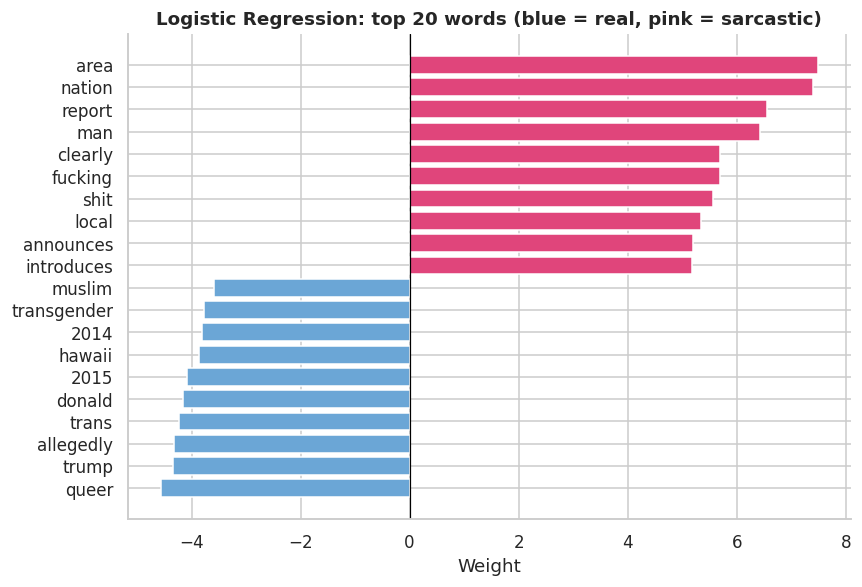

Top sarcastic: ['area', 'nation', 'report', 'man', 'clearly']
Top real     : ['queer', 'trump', 'allegedly', 'trans', 'donald']


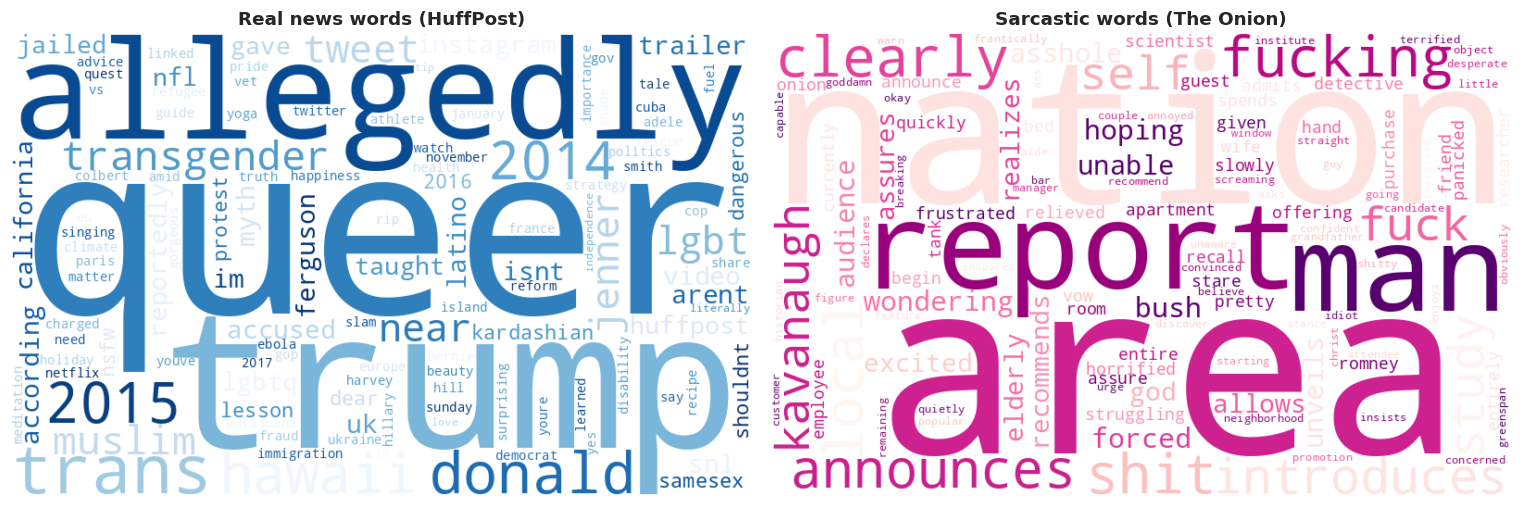

In [ ]:
feat_names = np.array(vec.get_feature_names_out()); weights = log_model.coef_[0]
order = np.argsort(weights)
top_real, top_sarc = list(feat_names[order[:10]]), list(feat_names[order[-10:]][::-1])
idx = np.concatenate([order[:10], order[-10:]])

plt.figure(figsize=(8, 5.5))
plt.barh(feat_names[idx], weights[idx], color=[C_REAL if weights[i] < 0 else C_SARC for i in idx])
plt.axvline(0, color='black', lw=0.8); plt.title('Logistic Regression: top 20 words (blue = real, pink = sarcastic)')
plt.xlabel('Weight'); plt.tight_layout(); save('04_lr_top_words'); plt.show()
print("Top sarcastic:", top_sarc[:5]); print("Top real     :", top_real[:5])

from wordcloud import WordCloud
uni = np.array([i for i, f in enumerate(feat_names) if ' ' not in f]); uw, uf = weights[uni], feat_names[uni]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, freq, cmap, title in [(ax[0], {uf[i]: float(-uw[i]) for i in np.argsort(uw)[:120]}, 'Blues', 'Real news words (HuffPost)'),
                             (ax[1], {uf[i]: float(uw[i]) for i in np.argsort(uw)[::-1][:120]}, 'RdPu', 'Sarcastic words (The Onion)')]:
    a.imshow(WordCloud(width=800, height=500, background_color='white', colormap=cmap,
                       prefer_horizontal=0.9).generate_from_frequencies(freq), interpolation='bilinear')
    a.axis('off'); a.set_title(title)
plt.tight_layout(); save('05_wordclouds'); plt.show()

### 8b. DistilBERT: LIME
LIME hides random words from a headline, watches how DistilBERT's answer changes, and fits a tiny linear model to those changes. The result is *which words pushed the prediction* (pink → sarcastic, blue → real). Unlike the LR weights this is an **approximation**, but it works on any model. First four individual headlines (a hit, a hit, a miss, and a stress-test text), then a global summary over 80 test headlines.

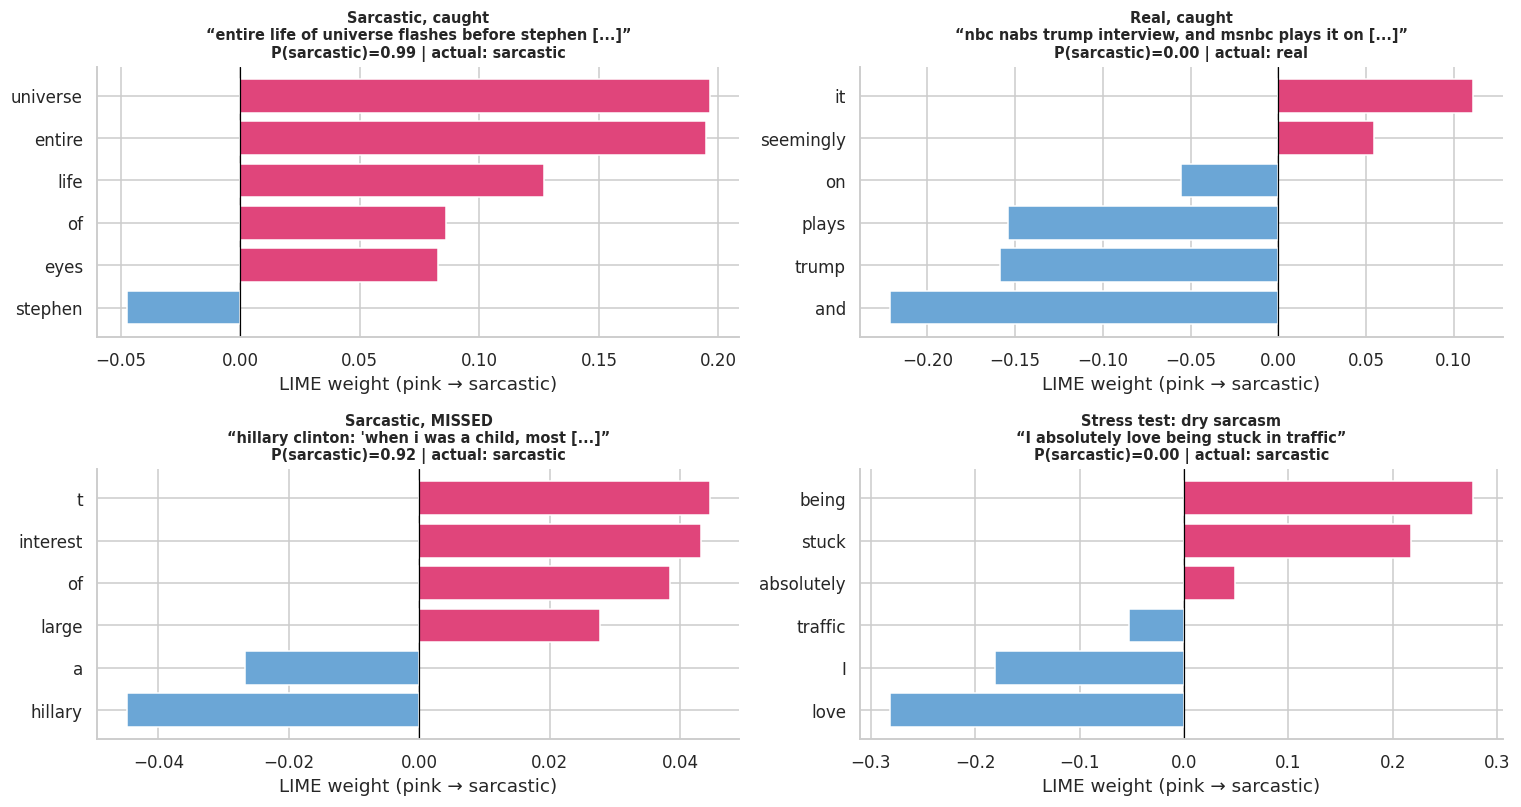

In [ ]:
try:
    from lime.lime_text import LimeTextExplainer
except ModuleNotFoundError:
    import os
    os.system('pip install -q lime')
    from lime.lime_text import LimeTextExplainer

import numpy as np
import matplotlib.pyplot as plt
import textwrap

lime_exp = LimeTextExplainer(class_names=['Real', 'Sarcastic'], random_state=SEED)

def bert_predict_proba(texts):
    # LIME needs an (n, 2) array of probabilities
    p = bert_proba(list(texts))
    return np.column_stack([1 - p, p])

pick = lambda mask: test[mask].sample(1, random_state=7).iloc[0]['headline']
examples = [('Sarcastic, caught', pick((test.is_sarcastic == 1) & (test.lr_prob > 0.75)), 1),
            ('Real, caught',      pick((test.is_sarcastic == 0) & (test.lr_prob < 0.25)), 0),
            ('Sarcastic, MISSED', pick((test.is_sarcastic == 1) & (test.lr_prob < 0.40)), 1),
            ('Stress test: dry sarcasm', 'I absolutely love being stuck in traffic', 1)]

fig, axs = plt.subplots(2, 2, figsize=(14, 7.5))
for a, (title, text, actual) in zip(axs.ravel(), examples):
    e = lime_exp.explain_instance(text, bert_predict_proba, num_features=6, num_samples=500)
    items = sorted(e.as_list(), key=lambda t: t[1])
    a.barh([w for w, _ in items], [v for _, v in items], color=[C_SARC if v > 0 else C_REAL for _, v in items])
    a.axvline(0, color='black', lw=0.8)
    a.set_title(f"{title}\n\u201c{textwrap.shorten(text, 55)}\u201d\nP(sarcastic)={bert_proba([text])[0]:.2f} | actual: {'sarcastic' if actual else 'real'}", fontsize=9.5)
    a.set_xlabel('LIME weight (pink → sarcastic)')
plt.tight_layout()
save('06_lime_local')
plt.show()

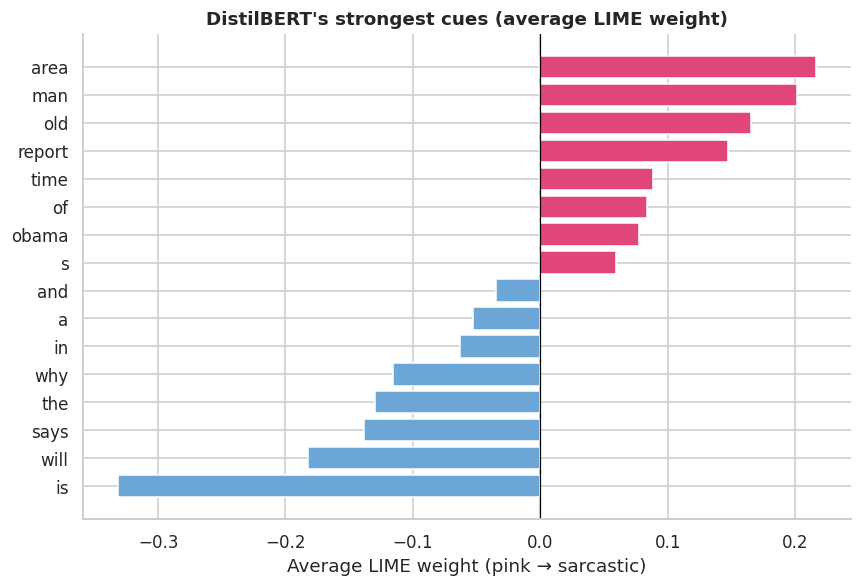

DistilBERT sarcastic cues: ['area', 'man', 'old', 'report', 'time']
DistilBERT real cues     : ['is', 'will', 'says', 'the', 'why']


In [ ]:
# Global LIME: average each word's LIME weight over 80 test headlines (40 sarcastic, 40 real)
try:
    from lime.lime_text import LimeTextExplainer
except ModuleNotFoundError:
    import os
    os.system('pip install -q lime')
    from lime.lime_text import LimeTextExplainer

from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

samp = pd.concat([test[test.is_sarcastic == 1].sample(40, random_state=1), test[test.is_sarcastic == 0].sample(40, random_state=1)])
agg = defaultdict(list)
for t in samp['headline']:
    for w, v in lime_exp.explain_instance(t, bert_predict_proba, num_features=8, num_samples=300).as_list():
        agg[w.lower()].append(v)
lime_global = (pd.DataFrame([(w, np.mean(v), len(v)) for w, v in agg.items() if len(v) >= 3],
                            columns=['word', 'mean_weight', 'count']).sort_values('mean_weight'))
show = pd.concat([lime_global.head(8), lime_global.tail(8)])
plt.figure(figsize=(8, 5.5))
plt.barh(show['word'], show['mean_weight'], color=[C_SARC if v > 0 else C_REAL for v in show['mean_weight']])
plt.axvline(0, color='black', lw=0.8); plt.title("DistilBERT's strongest cues (average LIME weight)")
plt.xlabel('Average LIME weight (pink → sarcastic)'); plt.tight_layout(); save('07_lime_global'); plt.show()
lime_top_sarc = list(lime_global.sort_values('mean_weight', ascending=False)['word'][:5])
lime_top_real = list(lime_global['word'][:5])
print("DistilBERT sarcastic cues:", lime_top_sarc); print("DistilBERT real cues     :", lime_top_real)

**Highlighter view.** The same LIME idea, drawn like a highlighter pen: the stronger the colour, the more that word pushed DistilBERT's answer. Pink → sarcastic, blue → real. This is the picture to show on a slide.

In [ ]:
from IPython.display import HTML

def highlight(text, n=400):
    e = lime_exp.explain_instance(text, bert_predict_proba, num_features=12, num_samples=n)
    wts = {w.lower(): v for w, v in e.as_list()}
    m = max([abs(v) for v in wts.values()] + [1e-9])
    chips = []
    for t in text.split():
        v = wts.get(re.sub(r'\W+', '', t).lower(), 0)
        a = min(abs(v) / m, 1) * 0.85
        col = f'rgba(224,69,123,{a:.2f})' if v > 0 else f'rgba(107,166,214,{a:.2f})'
        chips.append(f'<span style="background:{col};padding:3px 7px;border-radius:9px;margin:2px;display:inline-block">{t}</span>')
    return (f'<div style="font:16px sans-serif;margin:8px 0;padding:10px 14px;background:#fff;color:#333;border-radius:14px">'
            f'{"".join(chips)} &nbsp;<b>P(sarcastic) = {bert_proba([text])[0]:.2f}</b></div>')

demo = ["Area man wins argument with thermostat", "Senate passes bill to expand rural broadband access",
        "I absolutely love being stuck in traffic", "Local woman finally finishes watching one episode"]
display(HTML('<h4 style="font-family:sans-serif">Pink = pushes toward sarcastic · Blue = pushes toward real</h4>' + ''.join(highlight(t) for t in demo)))

## 9. Audit: does the baseline lean on a few outlet-style words?
Remove the words behind the 25 strongest weights on each side (about 49 distinct words), retrain Logistic Regression, and compare with removing the same number of **random** words. If accuracy falls much more for the top words, a small set of cues carries a large share of the signal. This is evidence, not proof: top-weight words are always the most informative, so the control matters.



In [ ]:
def retrain(banned):
    v = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, stop_words=list(ENGLISH_STOP_WORDS) + sorted(banned))
    m = LogisticRegression(C=best_C, max_iter=1000).fit(v.fit_transform(X_train), y_train)
    return accuracy_score(y_true, m.predict(v.transform(X_test)))

top_feats = list(feat_names[order[:25]]) + list(feat_names[order[-25:]])
banned_top = {w for f in top_feats for w in f.split()}
unigrams = [f for f in feat_names if ' ' not in f]
banned_rand = set(np.random.default_rng(SEED).choice(unigrams, len(banned_top), replace=False))
base_acc = accuracy_score(y_true, pred_log)
abl = pd.DataFrame({'Accuracy': [base_acc, retrain(banned_top), retrain(banned_rand)]},
                   index=['Baseline', f'Remove {len(banned_top)} top-weight words', f'Remove {len(banned_rand)} random words (control)'])
abl['Change (pts)'] = ((abl['Accuracy'] - base_acc) * 100).round(2); display(abl.round(4))

## 10. Stress test: does it detect sarcasm, or the outlet?
24 hand-written texts, 4 in each of 6 categories. Most are **not headlines**, so part of any failure is distribution shift, and 4 per category is tiny: read it as *indicative*. The dashed line is the score of a model that blindly answers "real" for everything (50%, because half the texts are sarcastic).



,Category,Text,Label,P(sarc) LR,P(sarc) BERT,LR correct,BERT correct
0,Onion-style sarcasm,Area man wins argument with thermostat,1,1.00,1.00,True,True
1,Onion-style sarcasm,Nation's dogs thrilled by new park,1,0.99,1.00,True,True
2,Onion-style sarcasm,Local woman finally finishes watching one episode,1,0.98,1.00,True,True
3,Onion-style sarcasm,Study finds area couple has run out of things ...,1,0.98,1.00,True,True
4,Dry sarcasm,I absolutely love being stuck in traffic,1,0.39,0.00,False,False
5,Dry sarcasm,"Oh great, another Monday meeting that could ha...",1,0.18,0.01,False,False
6,Dry sarcasm,"Wow, I just LOVE waiting two hours for custome...",1,0.83,0.01,True,False
7,Dry sarcasm,"Brilliant, my software crashed again",1,0.32,0.34,False,False
8,Explicit markers,"Yeah right, because that plan worked so well l...",1,0.60,0.30,True,False
9,Explicit markers,"Sure, because I totally wanted to work all wee...",1,0.55,0.02,True,False


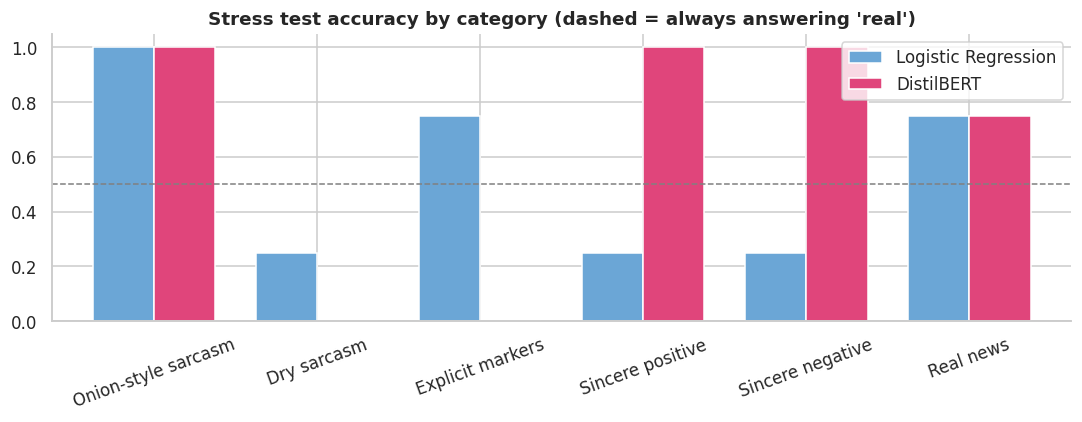

Overall  LR: 54% | DistilBERT: 62% (24 texts)
Sarcastic texts caught (12)  LR: 67% | DistilBERT: 33%


In [ ]:
T = [('Onion-style sarcasm', 1, ["Area man wins argument with thermostat", "Nation's dogs thrilled by new park",
                                  "Local woman finally finishes watching one episode",
                                  "Study finds area couple has run out of things to talk about"]),
     ('Dry sarcasm', 1, ["I absolutely love being stuck in traffic", "Oh great, another Monday meeting that could have been an email",
                         "Wow, I just LOVE waiting two hours for customer support", "Brilliant, my software crashed again"]),
     ('Explicit markers', 1, ["Yeah right, because that plan worked so well last time", "Sure, because I totally wanted to work all weekend",
                              "Oh sure, that's totally going to fix everything", "Great, another software update that fixes nothing /s"]),
     ('Sincere positive', 0, ["I really enjoyed the concert last night", "The new library opens to the public next month",
                              "Thank you all for the warm welcome today", "Our team is proud to announce the launch of a new app"]),
     ('Sincere negative', 0, ["My flight was cancelled and I am very upset", "The restaurant was disappointing and the service was slow",
                              "The package arrived damaged and nobody replied to my emails", "I am worried about my exam results"]),
     ('Real news', 0, ["Senate passes bill to expand rural broadband access", "Study finds regular exercise improves heart health",
                       "Scientists discover new species of frog in Ecuador", "Trump signs executive order on trade"])]

stress = pd.DataFrame([(c, t, l) for c, l, ts in T for t in ts], columns=['Category', 'Text', 'Label'])
stress['P(sarc) LR']   = log_model.predict_proba(vec.transform(stress['Text'].apply(clean_text)))[:, 1].round(2)
stress['P(sarc) BERT'] = bert_proba(stress['Text'].tolist()).round(2)
stress['LR correct']   = ((stress['P(sarc) LR'] >= 0.5).astype(int) == stress['Label'])
stress['BERT correct'] = ((stress['P(sarc) BERT'] >= 0.5).astype(int) == stress['Label'])
display(stress)

stress_cat = stress.groupby('Category', sort=False)[['LR correct', 'BERT correct']].mean().round(2)
stress_cat.columns = ['Logistic Regression', 'DistilBERT']
ax = stress_cat.plot(kind='bar', figsize=(10, 4), color=[C_REAL, C_SARC], rot=20, width=0.75)
ax.axhline(0.5, color='gray', ls='--', lw=1); ax.set_ylim(0, 1.05); ax.set_xlabel('')
ax.set_title("Stress test accuracy by category (dashed = always answering 'real')")
plt.tight_layout(); save('08_stress_test'); plt.show()
print("Overall  LR: {:.0%} | DistilBERT: {:.0%} (24 texts)".format(stress['LR correct'].mean(), stress['BERT correct'].mean()))
print("Sarcastic texts caught (12)  LR: {:.0%} | DistilBERT: {:.0%}".format(
    stress.loc[stress.Label == 1, 'LR correct'].mean(), stress.loc[stress.Label == 1, 'BERT correct'].mean()))

## 11. One-page model card

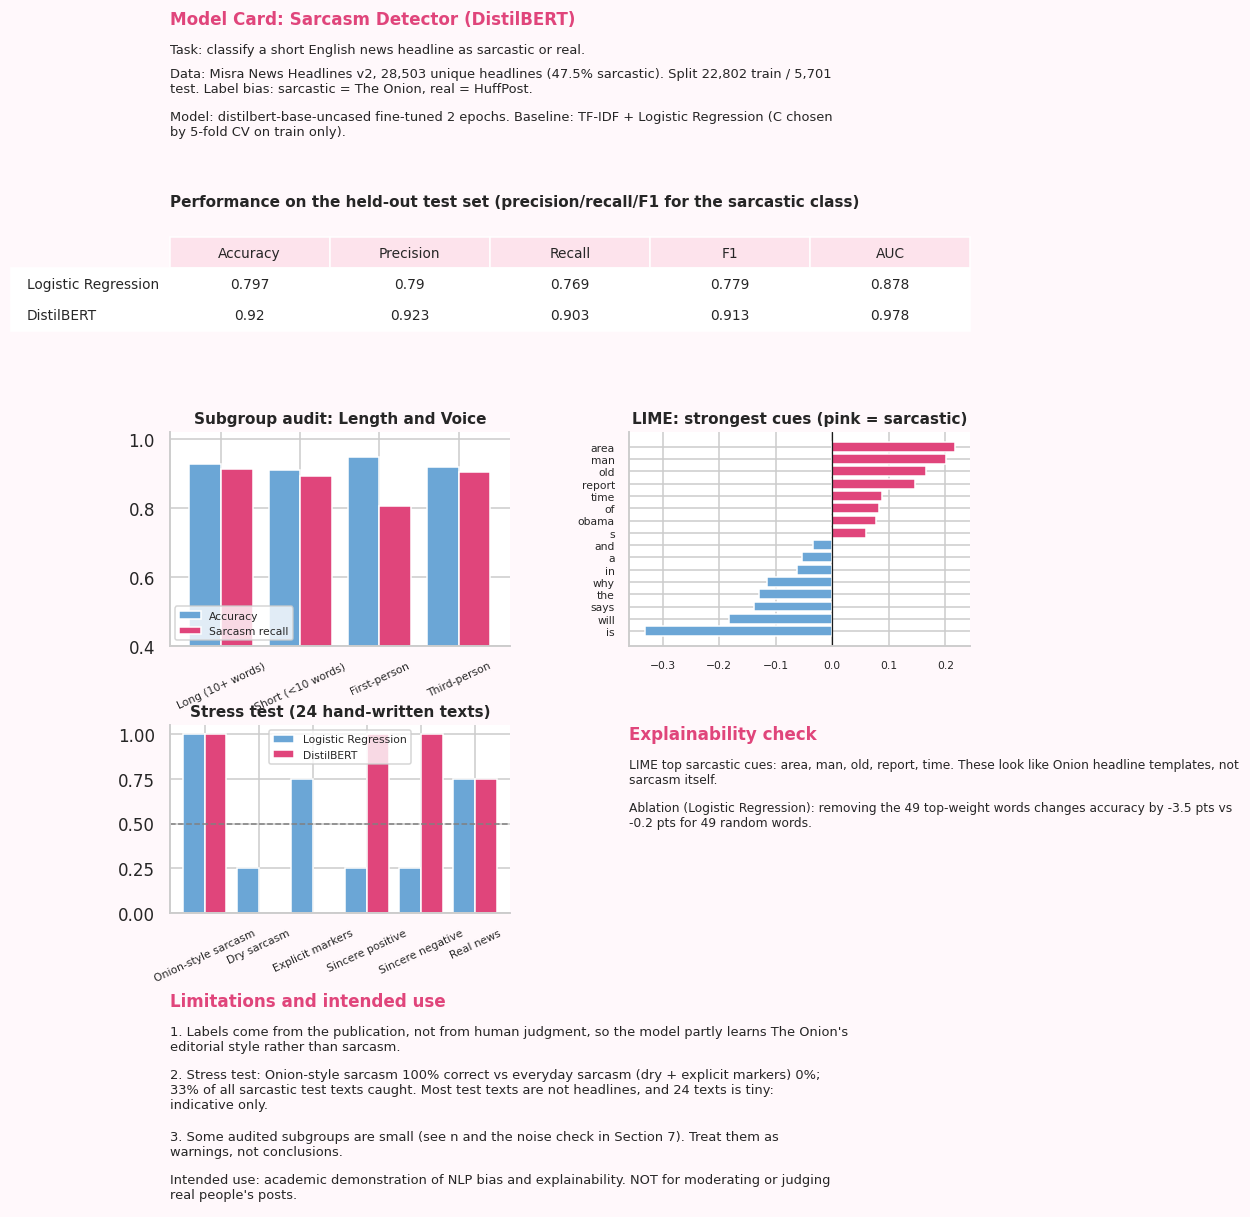

In [ ]:
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fallback calculation if the ablation section wasn't run or was deleted
if 'abl' not in globals():
    from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score

    def retrain(banned):
        v_ = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, stop_words=list(ENGLISH_STOP_WORDS) + sorted(banned))
        m_ = LogisticRegression(C=best_C, max_iter=1000).fit(v_.fit_transform(X_train), y_train)
        return accuracy_score(y_true, m_.predict(v_.transform(X_test)))

    top_feats = list(feat_names[order[:25]]) + list(feat_names[order[-25:]])
    banned_top = {w for f in top_feats for w in f.split()}
    unigrams = [f for f in feat_names if ' ' not in f]
    banned_rand = set(np.random.default_rng(SEED).choice(unigrams, len(banned_top), replace=False))
    base_acc = accuracy_score(y_true, pred_log)
    abl = pd.DataFrame({'Accuracy': [base_acc, retrain(banned_top), retrain(banned_rand)]},
                       index=['Baseline', f'Remove {len(banned_top)} top-weight words', f'Remove {len(banned_rand)} random words (control)'])
    abl['Change (pts)'] = ((abl['Accuracy'] - base_acc) * 100).round(2)

R = results
onion    = stress[stress.Category == 'Onion-style sarcasm']['BERT correct'].mean()
everyday = stress[stress.Category.isin(['Dry sarcasm', 'Explicit markers'])]['BERT correct'].mean()
caught   = stress.loc[stress.Label == 1, 'BERT correct'].mean()
d_top, d_rand = abl.iloc[1]['Change (pts)'], abl.iloc[2]['Change (pts)']

fig = plt.figure(figsize=(8.27, 11.69), facecolor='#FFF8FB')
gs = fig.add_gridspec(5, 2, height_ratios=[1.0, 1.1, 1.7, 1.5, 1.7], hspace=0.45, wspace=0.35,
                      left=0.07, right=0.95, top=0.96, bottom=0.03)

def block(ax, title, lines, size=8.5):
    ax.axis('off'); H = ax.get_position().height * fig.get_figheight(); lh = 0.17 / H
    ax.text(0, 1, title, fontsize=11, fontweight='bold', color=C_SARC, va='top', transform=ax.transAxes)
    y = 1 - 0.30 / H
    for ln in lines:
        t = textwrap.fill(ln, 100); ax.text(0, y, t, fontsize=size, va='top', transform=ax.transAxes)
        y -= lh * (t.count('\n') + 1) + 0.05 / H

block(fig.add_subplot(gs[0, :]), 'Model Card: Sarcasm Detector (DistilBERT)', [
    'Task: classify a short English news headline as sarcastic or real.',
    f'Data: Misra News Headlines v2, {len(df):,} unique headlines ({df.is_sarcastic.mean():.1%} sarcastic). Split {len(X_train):,} train / {len(X_test):,} test. Label bias: sarcastic = The Onion, real = HuffPost.',
    'Model: distilbert-base-uncased fine-tuned 2 epochs. Baseline: TF-IDF + Logistic Regression (C chosen by 5-fold CV on train only).'])

ax = fig.add_subplot(gs[1, :]); ax.axis('off')
tbl = R.loc[['Logistic Regression', 'DistilBERT'], ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].round(3)
t = ax.table(cellText=tbl.values, rowLabels=tbl.index, colLabels=tbl.columns, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.7)
for (r, c), cell in t.get_celld().items():
    cell.set_edgecolor('white'); cell.set_facecolor('#FDE3EC' if r == 0 else '#FFFFFF')
ax.set_title('Performance on the held-out test set (precision/recall/F1 for the sarcastic class)', fontsize=10, fontweight='bold', loc='left')

ax = fig.add_subplot(gs[2, 0])
sub = audit_df[(audit_df.Model == 'DistilBERT') & audit_df.Axis.isin(['Length', 'Voice'])].set_index('Group')[['Accuracy', 'Sarcasm recall']]
sub.plot(kind='bar', ax=ax, color=[C_REAL, C_SARC], rot=25, width=.8); ax.set_ylim(0.4, 1.02); ax.set_xlabel('')
ax.set_title('Subgroup audit: Length and Voice', fontsize=10, fontweight='bold'); ax.legend(fontsize=7, loc='lower left')
ax.tick_params(axis='x', labelsize=7)

ax = fig.add_subplot(gs[2, 1])
ax.barh(show['word'], show['mean_weight'], color=[C_SARC if v > 0 else C_REAL for v in show['mean_weight']])
ax.axvline(0, color='k', lw=.8); ax.set_title('LIME: strongest cues (pink = sarcastic)', fontsize=10, fontweight='bold'); ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[3, 0])
stress_cat.plot(kind='bar', ax=ax, color=[C_REAL, C_SARC], rot=25, width=.8); ax.axhline(.5, color='gray', ls='--', lw=1)
ax.set_ylim(0, 1.05); ax.set_xlabel(''); ax.set_title('Stress test (24 hand-written texts)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7); ax.tick_params(axis='x', labelsize=7)

block(fig.add_subplot(gs[3, 1]), 'Explainability check', [
    f'LIME top sarcastic cues: {", ".join(lime_top_sarc)}. These look like Onion headline templates, not sarcasm itself.',
    f'Ablation (Logistic Regression): removing the 49 top-weight words changes accuracy by {d_top:+.1f} pts vs {d_rand:+.1f} pts for 49 random words.'], size=8)

block(fig.add_subplot(gs[4, :]), 'Limitations and intended use', [
    '1. Labels come from the publication, not from human judgment, so the model partly learns The Onion\'s editorial style rather than sarcasm.',
    f'2. Stress test: Onion-style sarcasm {onion:.0%} correct vs everyday sarcasm (dry + explicit markers) {everyday:.0%}; {caught:.0%} of all sarcastic test texts caught. Most test texts are not headlines, and 24 texts is tiny: indicative only.',
    '3. Some audited subgroups are small (see n and the noise check in Section 7). Treat them as warnings, not conclusions.',
    'Intended use: academic demonstration of NLP bias and explainability. NOT for moderating or judging real people\'s posts.'])
fig.savefig('figs/model_card.png', dpi=200); fig.savefig('figs/model_card.pdf'); plt.show()

## 12. Export data for the website prototype
This cell saves your **real** results as `website_data.json` and prints one line (`const DATA = ...`). Paste that line into the website's `<script>` (replace the existing `const DATA = ...`) and the demo uses your own model's numbers and word weights.

In [ ]:
import json
uni = [i for i, f in enumerate(feat_names) if ' ' not in f]
uw, uf = weights[uni], feat_names[uni]; o = np.argsort(uw)
wt = {uf[i]: round(float(uw[i]), 2) for i in list(o[:50]) + list(o[-50:])}
met = lambda n: {'acc': round(float(results.loc[n, 'Accuracy']), 3), 'f1': round(float(results.loc[n, 'F1']), 3), 'auc': round(float(results.loc[n, 'AUC']), 3)}
sub = []
for g in audit_df.Group.unique():
    r = audit_df[audit_df.Group == g]
    sub.append({'g': g, 'n': int(r.n.iloc[0]),
                'lr': round(float(r[r.Model == 'Logistic Regression'].Accuracy.iloc[0]), 3),
                'bert': round(float(r[r.Model == 'DistilBERT'].Accuracy.iloc[0]), 3)})
data = {'metrics': {'lr': met('Logistic Regression'), 'bert': met('DistilBERT')}, 'weights': wt, 'subgroups': sub}
json.dump(data, open('website_data.json', 'w'))
print('const DATA = ' + json.dumps(data) + ';')
try:
    from google.colab import files; files.download('website_data.json'); files.download('figs/model_card.pdf')
except Exception: pass

const DATA = {"metrics": {"lr": {"acc": 0.797, "f1": 0.779, "auc": 0.878}, "bert": {"acc": 0.92, "f1": 0.913, "auc": 0.978}}, "weights": {"queer": -4.57, "trump": -4.35, "allegedly": -4.33, "trans": -4.22, "donald": -4.15, "2015": -4.08, "hawaii": -3.87, "2014": -3.8, "transgender": -3.77, "muslim": -3.6, "jenner": -3.53, "lgbt": -3.43, "near": -3.41, "tweet": -3.4, "instagram": -3.38, "accused": -3.32, "trailer": -3.32, "isnt": -3.3, "reportedly": -3.3, "im": -3.28, "according": -3.28, "video": -3.28, "arent": -3.24, "latino": -3.21, "myth": -3.2, "uk": -3.18, "ferguson": -3.09, "snl": -2.99, "huffpost": -2.99, "jailed": -2.95, "taught": -2.95, "california": -2.95, "lgbtq": -2.94, "gave": -2.93, "nfl": -2.93, "kardashian": -2.93, "lesson": -2.92, "dangerous": -2.92, "samesex": -2.91, "dear": -2.91, "nsfw": -2.91, "shouldnt": -2.9, "protest": -2.9, "2016": -2.86, "immigration": -2.86, "november": -2.85, "watch": -2.84, "guide": -2.84, "paris": -2.83, "gop": -2.83, "given": 3.02, "entir

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>